In [1]:
import pandas as pd
import glob

cols = ['open_time','open','high','low','close','volume',
        'close_time','quote_volume','trades','taker_buy_base',
        'taker_buy_quote','ignore']

BASE = '/home/onyxia/work/binance-public-data/python/data/spot/monthly/klines'

def load_symbol(symbol):
    files = sorted(glob.glob(f'{BASE}/{symbol}/1h/**/*.zip', recursive=True))
    print(f"{symbol}: {len(files)} fichiers trouvés")
    dfs = [pd.read_csv(f, names=cols) for f in files]
    df = pd.concat(dfs, ignore_index=True)

    t = pd.to_numeric(df['open_time'], errors='coerce')
    df = df[t.notna()]
    t = t[t.notna()]
    t = (t / 1000).where(t > 1e14, t)
    df['open_time'] = pd.to_datetime(t, unit='ms')

    df = df.set_index('open_time').sort_index()
    return df['close'].astype(float).rename(symbol)

btc = load_symbol('BTCUSDT')
eth = load_symbol('ETHUSDT')
sol = load_symbol('SOLUSDT')


prices = pd.concat([btc, eth, sol], axis=1).dropna().reset_index()
print(prices.shape)

BTCUSDT: 6 fichiers trouvés
ETHUSDT: 6 fichiers trouvés
SOLUSDT: 6 fichiers trouvés
(4344, 4)


In [2]:
from Pipeline import adf_manuel,pipeline

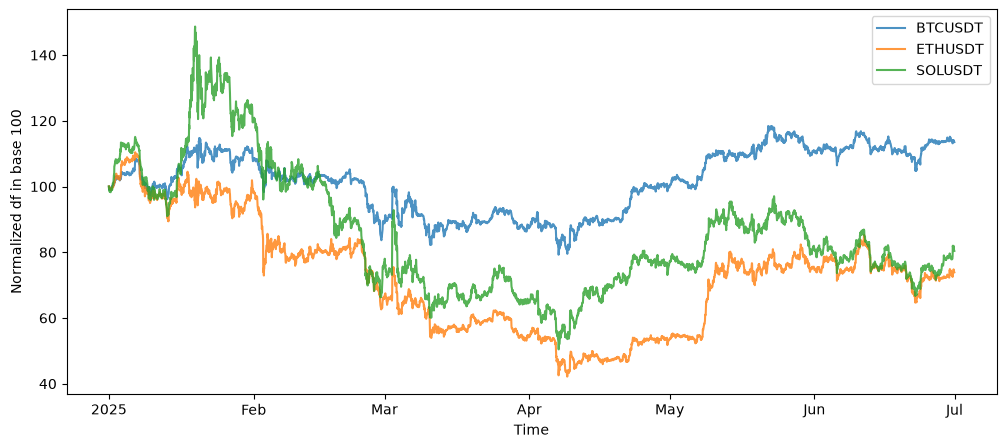

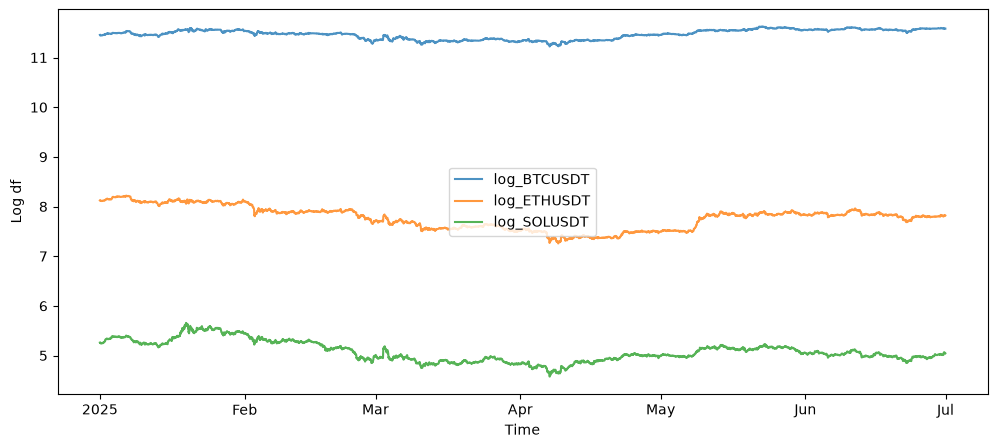

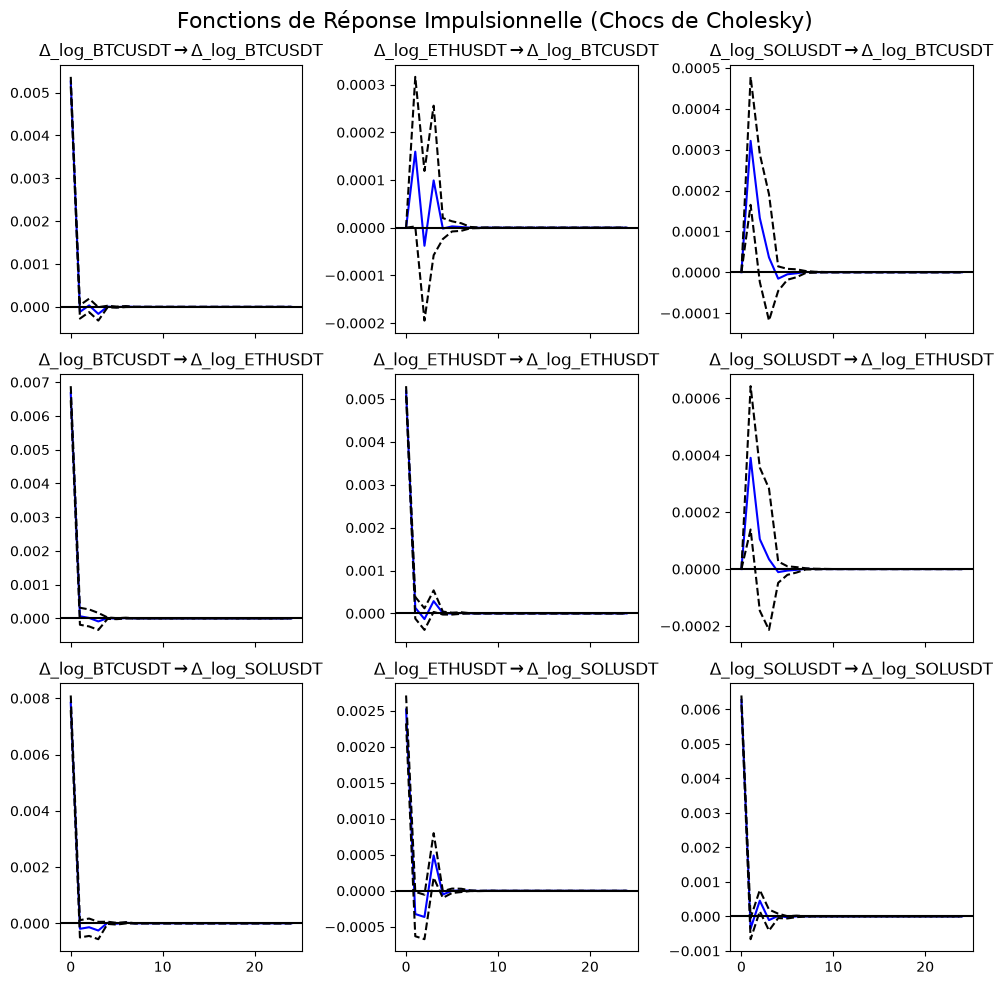

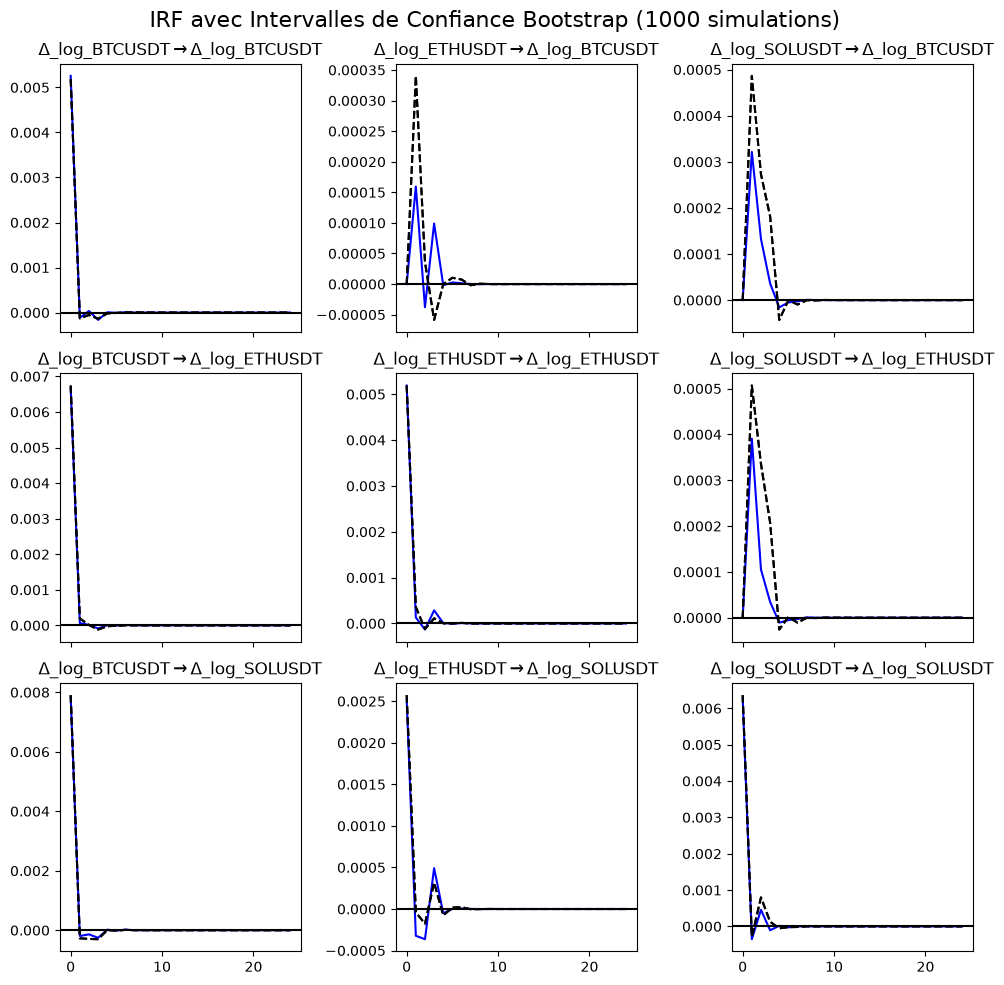

In [3]:
pipeline(prices)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ARCH_GARCH import opti_AR_ARCH,log_vraisemblance

In [37]:
prices['Δ_log_BTC'] = np.log(prices['BTCUSDT']).diff()
prices = prices.dropna(subset=['Δ_log_BTC'])

In [38]:
prices['Δ_log_BTC'].head(10)

1    -0.008440
2     0.005233
3    -0.002776
4    -0.003032
5     0.002542
6    -0.000367
7    -0.000784
8    -0.002732
9    -0.000165
10   -0.000930
Name: Δ_log_BTC, dtype: float64

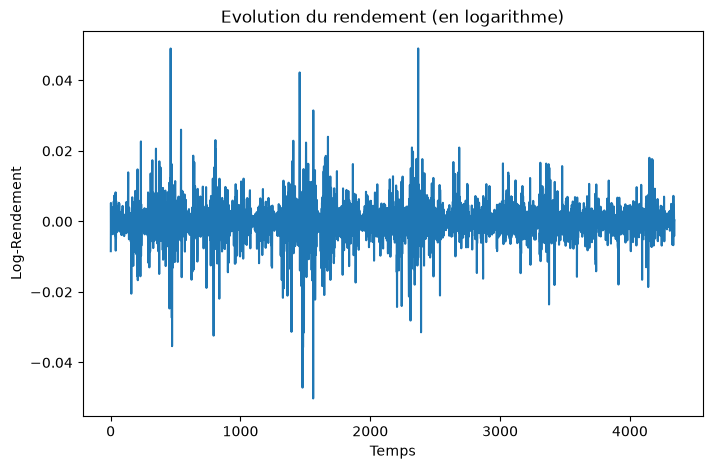

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(prices['Δ_log_BTC'])
plt.title('Evolution du rendement (en logarithme)')
plt.xlabel('Temps')
plt.ylabel('Log-Rendement')
plt.show()

In [40]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

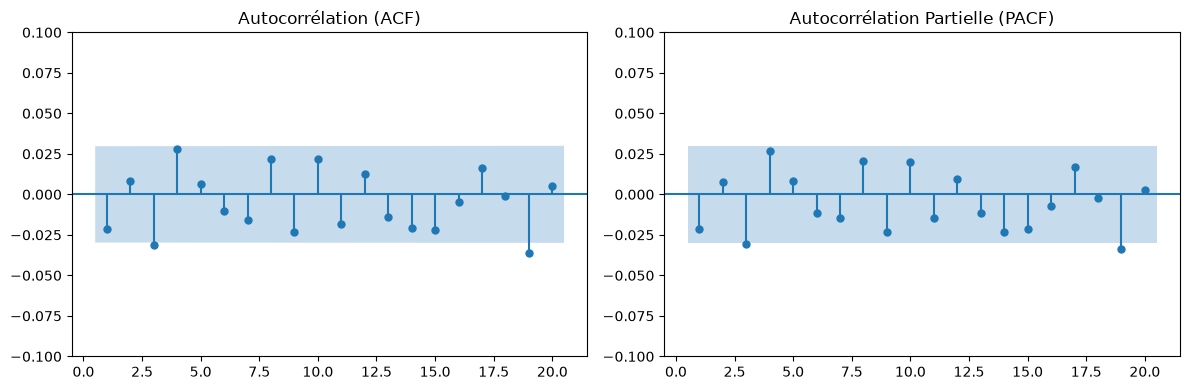

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(prices['Δ_log_BTC'], ax=axes[0], lags=20, alpha=0.05, zero=False, title="Autocorrélation (ACF)")
plot_pacf(prices['Δ_log_BTC'], ax=axes[1], lags=20, alpha=0.05, zero=False, title="Autocorrélation Partielle (PACF)")

axes[0].set_ylim(-0.1, 0.1)
axes[1].set_ylim(-0.1, 0.1)

plt.tight_layout()
plt.show()

In [46]:
valeurs_acf = acf(prices['Δ_log_BTC'], nlags=20)
valeurs_pacf = pacf(prices['Δ_log_BTC'], nlags=20)

print(valeurs_acf)
print(valeurs_pacf)

[ 1.         -0.02151323  0.00833143 -0.03121236  0.0282147   0.00648578
 -0.01025421 -0.01569953  0.0215834  -0.02349028  0.02171304 -0.01804903
  0.01262681 -0.01406917 -0.02072297 -0.02197243 -0.00497642  0.01643044
 -0.00117677 -0.03631102  0.00512205]
[ 1.         -0.02151818  0.00787589 -0.03090274  0.02689618  0.00813466
 -0.01136617 -0.01461316  0.02090955 -0.02357634  0.02017177 -0.01467029
  0.00925519 -0.01160699 -0.0230296  -0.02152556 -0.00728828  0.017005
 -0.00197656 -0.034173    0.0029801 ]


In [ ]:
#Let's try to fit a AR-ARCH(1,1):
prices['Δ_log_BTC']=np.array(prices['Δ_log_BTC'])

moyenne_empirique=np.mean(prices['Δ_log_BTC'])
variance_empirique=np.mean((prices['Δ_log_BTC']-moyenne_empirique)**2)

print(moyenne_empirique,vol_empirique)

2.9160466854094204e-05 2.7776143336453397e-05


In [ ]:
parametres_initiaux

opti_AR_ARCH(log_vraisemblance,[moyenne_empirique*(1-valeurs_acf[1]),valeurs_acf[1],],actif)